# Lab07 – Generación, Limpieza y Transformación de un DataSet
### El Principio GIGO (Garbage In, Garbage Out)

| | |
|---|---|
| **Fecha** | 28 de mayo del 2026 |
| **Autor** | Rodolfo Lopez Cruz |

---

## Objetivo General
Identificar problemas de calidad de datos, aplicar técnicas de limpieza y transformación,
y analizar cómo los datos incorrectos afectan el análisis y los modelos de Machine Learning
mediante el principio **GIGO**.


## 1. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Estilo global
plt.rcParams.update({'figure.dpi': 130, 'figure.facecolor': 'white'})
sns.set_theme(style='whitegrid', palette='muted')

print("✅ Librerías cargadas correctamente.")


✅ Librerías cargadas correctamente.


## 2. Carga del Dataset Original

In [2]:
df_raw = pd.read_csv('ventas-por-factura.csv')
print(f"Dimensiones: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")
df_raw.head(10)


Dimensiones: 25,953 filas × 6 columnas


,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
0,548370,3/30/2021 16:14:00,15528.0,United Kingdom,123,"229,33"
1,575767,11/11/2021 11:11:00,17348.0,United Kingdom,163,"209,73"
2,C570727,10/12/2021 11:32:00,12471.0,Germany,-1,"-1,45"
3,549106,4/6/2021 12:08:00,17045.0,United Kingdom,1,"39,95"
4,573112,10/27/2021 15:33:00,16416.0,United Kingdom,357,"344,83"
5,576630,11/16/2021 8:38:00,13816.0,Germany,91,"199,98"
6,538125,12/9/2020 15:46:00,18225.0,United Kingdom,16,"30,00"
7,544354,2/18/2021 10:42:00,13489.0,United Kingdom,64,"77,28"
8,546369,3/11/2021 11:41:00,15513.0,United Kingdom,10,"67,50"
9,570651,10/11/2021 13:34:00,14911.0,EIRE,86,"321,35"


## 3. Exploración General

In [3]:
print("=== Tipos de datos ===")
print(df_raw.dtypes)
print()
print("=== Estadísticas descriptivas (columnas numéricas) ===")
display(df_raw.describe())


=== Tipos de datos ===
N° de factura           str
Fecha de factura        str
ID Cliente          float64
País                    str
Cantidad              int64
Monto                   str
dtype: object

=== Estadísticas descriptivas (columnas numéricas) ===


,ID Cliente,Cantidad
count,22229.000000,25953.000000
mean,15238.289892,199.474049
std,1732.981685,1107.075809
min,12346.000000,-80995.000000
25%,13755.000000,6.000000
50%,15136.000000,100.000000
75%,16746.000000,240.000000
max,18287.000000,80995.000000


## 4. Identificación de Problemas de Calidad

Se identifican los siguientes problemas:

| # | Problema | Descripción |
|---|----------|-------------|
| 1 | **Valores nulos** | Columna `ID Cliente` presenta valores faltantes |
| 2 | **Outliers / Negativos** | `Cantidad` y `Monto` con valores negativos |
| 3 | **Datos inválidos** | `Monto` almacenado como texto con coma decimal |
| 4 | **Facturas canceladas** | `N° de factura` que inician con la letra **C** |
| 5 | **Duplicados** | Filas completamente repetidas |
| 6 | **Formato de fecha** | `Fecha de factura` es tipo `object`, no `datetime` |


In [4]:
# ── 4.1 Valores nulos ────────────────────────────────────────────────────────
nulos = df_raw.isnull().sum()
pct   = (nulos / len(df_raw) * 100).round(2)
resumen_nulos = pd.DataFrame({'Nulos': nulos, '% del total': pct})
print("=== 4.1 Valores Nulos ===")
display(resumen_nulos[resumen_nulos['Nulos'] > 0])

# ── 4.2 Facturas canceladas ──────────────────────────────────────────────────
canceladas = df_raw[df_raw['N° de factura'].astype(str).str.startswith('C')]
print(f"\n=== 4.2 Facturas Canceladas === → {len(canceladas):,} registros ({len(canceladas)/len(df_raw)*100:.1f}%)")
display(canceladas.head(5))

# ── 4.3 Valores negativos ────────────────────────────────────────────────────
neg_cantidad = df_raw[df_raw['Cantidad'] < 0]
print(f"\n=== 4.3 Cantidad negativa === → {len(neg_cantidad):,} registros")
display(neg_cantidad.head(5))

# ── 4.4 Monto como texto (coma decimal) ─────────────────────────────────────
print(f"\n=== 4.4 Tipo de dato 'Monto' === → {df_raw['Monto'].dtype}")
print("Ejemplos con coma:", df_raw['Monto'].head(5).tolist())

# ── 4.5 Duplicados ───────────────────────────────────────────────────────────
dup = df_raw.duplicated().sum()
print(f"\n=== 4.5 Duplicados === → {dup} filas completamente duplicadas")

# ── 4.6 Formato de fechas ────────────────────────────────────────────────────
print(f"\n=== 4.6 Tipo 'Fecha de factura' === → {df_raw['Fecha de factura'].dtype}")
print(df_raw['Fecha de factura'].head(3).tolist())


=== 4.1 Valores Nulos ===


,Nulos,% del total
ID Cliente,3724,14.35



=== 4.2 Facturas Canceladas === → 3,841 registros (14.8%)


,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
2,C570727,10/12/2021 11:32:00,12471.0,Germany,-1,"-1,45"
10,C543628,2/10/2021 15:51:00,16558.0,United Kingdom,-5,"-9,25"
17,C553508,5/17/2021 13:44:00,14000.0,United Kingdom,-3,"-1,95"
20,C577693,11/21/2021 11:48:00,12628.0,Germany,-3,"-16,85"
22,C547309,3/22/2021 11:17:00,17416.0,United Kingdom,-12,"-45,00"



=== 4.3 Cantidad negativa === → 5,179 registros


,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
2,C570727,10/12/2021 11:32:00,12471.0,Germany,-1,"-1,45"
10,C543628,2/10/2021 15:51:00,16558.0,United Kingdom,-5,"-9,25"
16,542418,1/27/2021 17:39:00,NaN,United Kingdom,-17,"0,00"
17,C553508,5/17/2021 13:44:00,14000.0,United Kingdom,-3,"-1,95"
20,C577693,11/21/2021 11:48:00,12628.0,Germany,-3,"-16,85"



=== 4.4 Tipo de dato 'Monto' === → str
Ejemplos con coma: ['229,33', '209,73', '-1,45', '39,95', '344,83']

=== 4.5 Duplicados === → 10 filas completamente duplicadas

=== 4.6 Tipo 'Fecha de factura' === → str
['3/30/2021 16:14:00', '11/11/2021 11:11:00', '10/12/2021 11:32:00']


## 5. Gráficas de Identificación de Anomalías
### 5.1 Heatmap de Valores Nulos

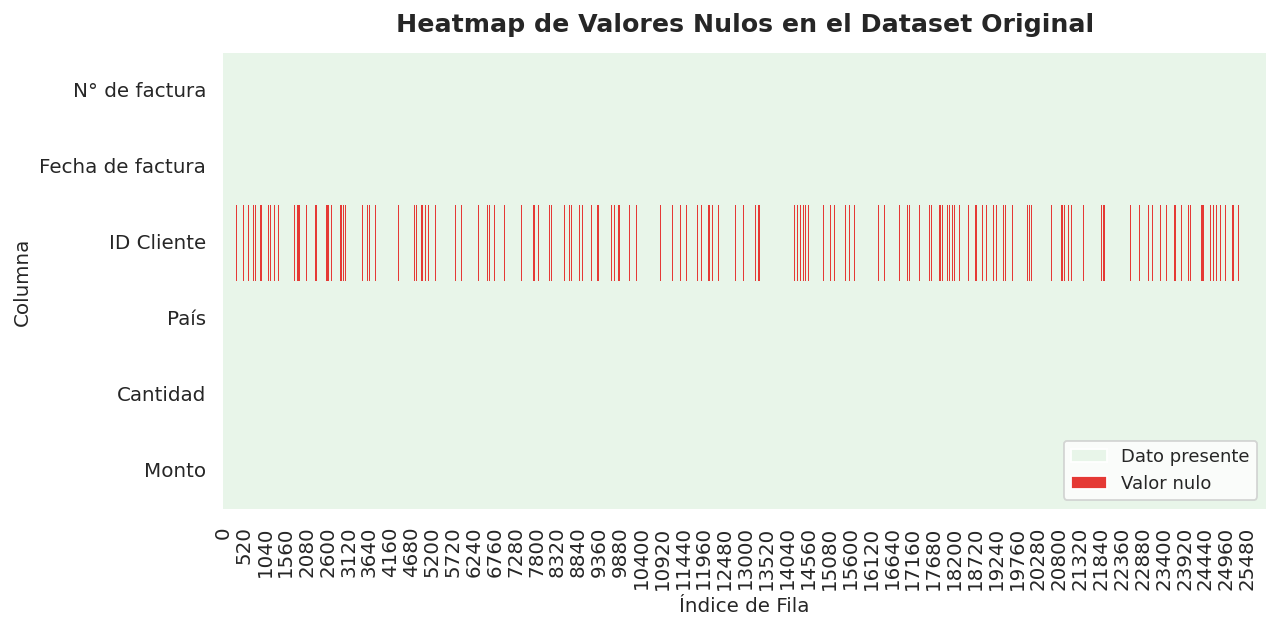

📊 Heatmap guardado.


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

# Construir matriz binaria de nulos
null_matrix = df_raw.isnull().astype(int)

sns.heatmap(
    null_matrix.T,
    cmap=['#E8F5E9', '#E53935'],
    cbar=False,
    linewidths=0,
    ax=ax,
    yticklabels=df_raw.columns
)
ax.set_title('Heatmap de Valores Nulos en el Dataset Original', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Índice de Fila', fontsize=11)
ax.set_ylabel('Columna', fontsize=11)
ax.tick_params(left=False, bottom=False)

# Leyenda manual
from matplotlib.patches import Patch
legend_els = [Patch(facecolor='#E8F5E9', label='Dato presente'),
              Patch(facecolor='#E53935', label='Valor nulo')]
ax.legend(handles=legend_els, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('heatmap_nulos.png', dpi=130, bbox_inches='tight')
plt.show()
print("📊 Heatmap guardado.")


### 5.2 Ventas por País (Dataset Original)

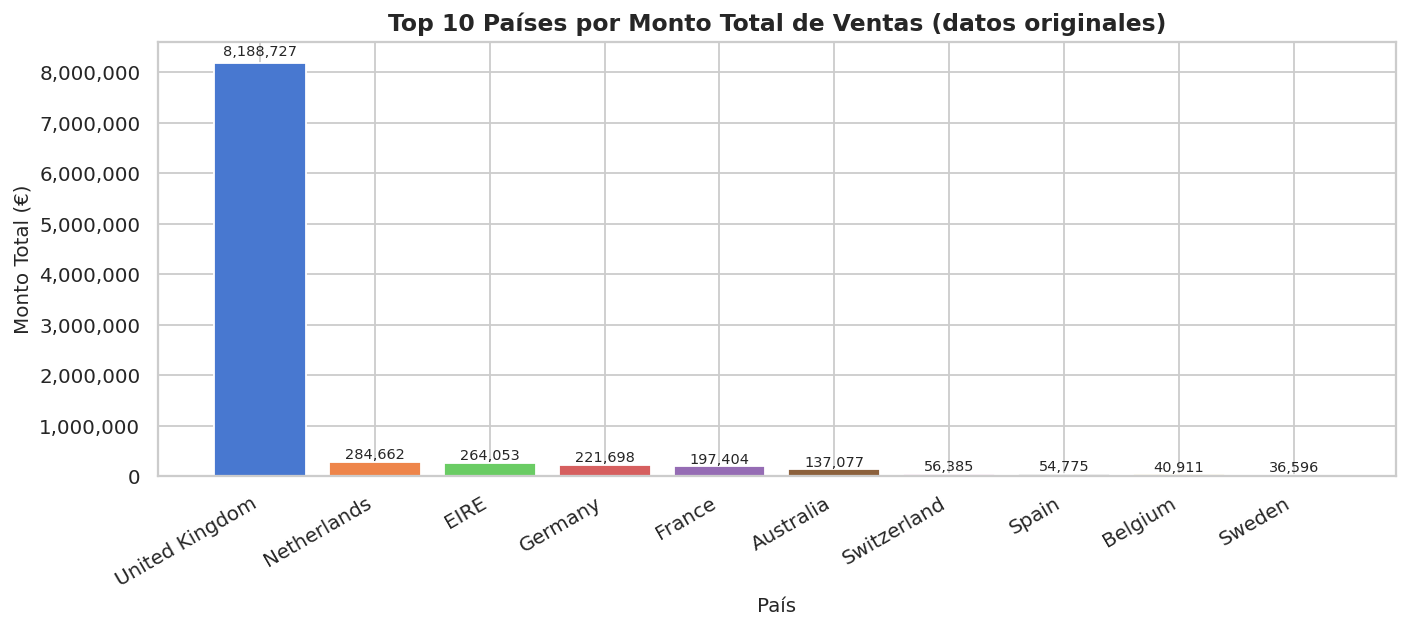

📊 Gráfica ventas por país guardada.


In [6]:
# Convertir Monto a numérico para la gráfica (aun con datos sucios)
monto_tmp = df_raw['Monto'].astype(str).str.replace(',', '.').str.replace(' ', '')
monto_tmp = pd.to_numeric(monto_tmp, errors='coerce')

ventas_pais = (
    df_raw.assign(Monto_num=monto_tmp)
          .groupby('País')['Monto_num']
          .sum()
          .sort_values(ascending=False)
          .head(10)
)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(ventas_pais.index, ventas_pais.values,
              color=sns.color_palette('muted', len(ventas_pais)))
ax.set_title('Top 10 Países por Monto Total de Ventas (datos originales)', fontsize=13, fontweight='bold')
ax.set_xlabel('País', fontsize=11)
ax.set_ylabel('Monto Total (€)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=30, ha='right')

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + h*0.01,
            f'{h:,.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('ventas_por_pais_original.png', dpi=130, bbox_inches='tight')
plt.show()
print("📊 Gráfica ventas por país guardada.")


### 5.3 Distribución del Monto (Dataset Original)

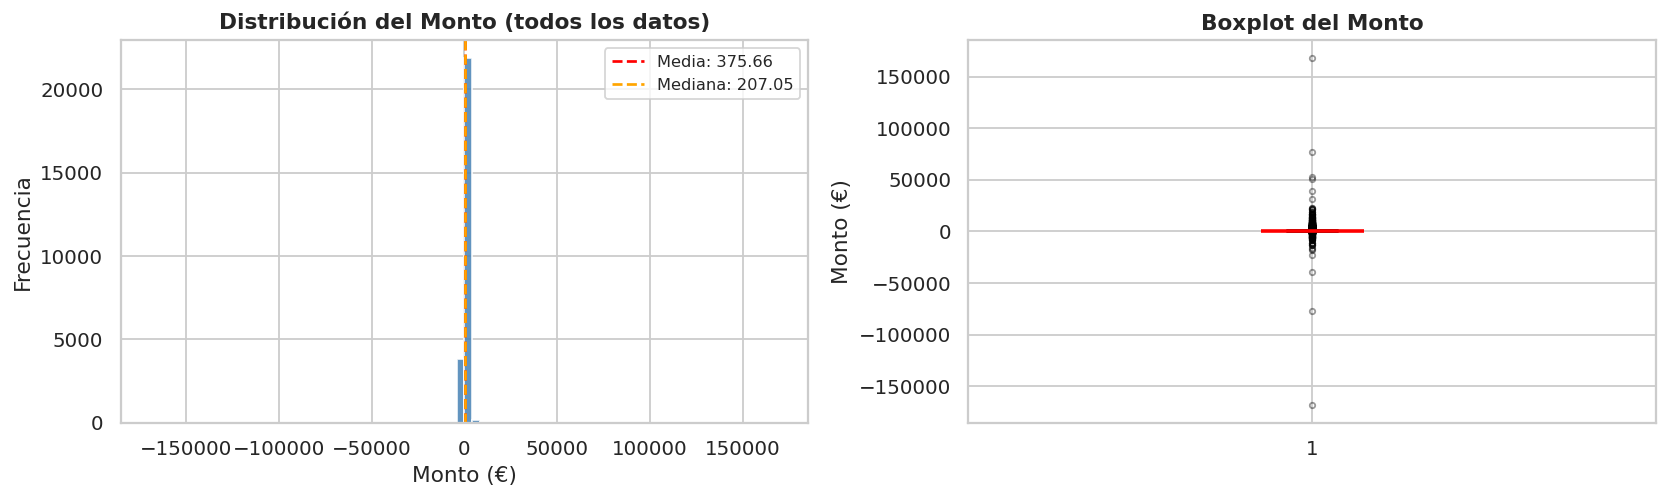

📊 Gráfica distribución del monto guardada.


In [7]:
monto_num = df_raw['Monto'].astype(str).str.replace(',', '.').str.replace(' ', '')
monto_num = pd.to_numeric(monto_num, errors='coerce').dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma
axes[0].hist(monto_num, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribución del Monto (todos los datos)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Monto (€)')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(monto_num.mean(), color='red',   linestyle='--', linewidth=1.5, label=f'Media: {monto_num.mean():.2f}')
axes[0].axvline(monto_num.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Mediana: {monto_num.median():.2f}')
axes[0].legend(fontsize=9)

# Boxplot
axes[1].boxplot(monto_num, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'),
                medianprops=dict(color='red', linewidth=2),
                flierprops=dict(marker='o', markersize=3, alpha=0.4))
axes[1].set_title('Boxplot del Monto', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Monto (€)')

plt.tight_layout()
plt.savefig('distribucion_monto.png', dpi=130, bbox_inches='tight')
plt.show()
print("📊 Gráfica distribución del monto guardada.")


## 6. Limpieza del Dataset

### Decisiones de limpieza y justificación

| Acción | Justificación |
|--------|--------------|
| **Eliminar facturas canceladas (C…)** | Las facturas canceladas no representan ventas reales; incluirlas distorsionaría el total de ingresos y los modelos de ML aprenderían patrones erróneos. |
| **Eliminar duplicados** | Las filas idénticas duplican artificialmente el volumen de datos y sesgan métricas como suma o media. |
| **Eliminar filas con Cantidad negativa** | Cantidades negativas son inconsistentes con el concepto de venta; pueden indicar devoluciones no etiquetadas. |
| **Eliminar nulos en ID Cliente** | Sin identificador de cliente no es posible segmentar ni construir modelos de comportamiento de compra. |
| **Convertir Monto a float** | El formato texto con coma decimal impide realizar cualquier operación matemática o estadística. |
| **Convertir Fecha a datetime** | El tipo `object` impide extraer año, mes, día o calcular rangos temporales. |


In [8]:
df = df_raw.copy()

print(f"Registros ANTES de limpiar: {len(df):,}")

# ── 6.1 Eliminar facturas canceladas ────────────────────────────────────────
mask_canceladas = df['N° de factura'].astype(str).str.startswith('C')
n_canceladas = mask_canceladas.sum()
df = df[~mask_canceladas]
print(f"  – Facturas canceladas eliminadas : {n_canceladas:,}")

# ── 6.2 Eliminar duplicados ──────────────────────────────────────────────────
n_dup = df.duplicated().sum()
df = df.drop_duplicates()
print(f"  – Duplicados eliminados          : {n_dup:,}")

# ── 6.3 Eliminar filas con Cantidad negativa ─────────────────────────────────
n_neg = (df['Cantidad'] < 0).sum()
df = df[df['Cantidad'] >= 0]
print(f"  – Filas con Cantidad negativa    : {n_neg:,}")

# ── 6.4 Eliminar nulos en ID Cliente ────────────────────────────────────────
n_nulos_id = df['ID Cliente'].isnull().sum()
df = df.dropna(subset=['ID Cliente'])
print(f"  – Nulos en ID Cliente eliminados : {n_nulos_id:,}")

print(f"\nRegistros DESPUÉS de limpiar: {len(df):,}")


Registros ANTES de limpiar: 25,953
  – Facturas canceladas eliminadas : 3,841
  – Duplicados eliminados          : 6
  – Filas con Cantidad negativa    : 1,336
  – Nulos en ID Cliente eliminados : 2,204

Registros DESPUÉS de limpiar: 18,566


## 7. Transformación de Datos

In [9]:
# ── 7.1 Monto: coma → punto y convertir a float ────────────────────────────
df['Monto'] = (df['Monto']
               .astype(str)
               .str.replace(',', '.', regex=False)
               .str.strip())
df['Monto'] = pd.to_numeric(df['Monto'], errors='coerce')
print(f"Monto dtype después: {df['Monto'].dtype}")
print(f"Valores NaN en Monto tras conversión: {df['Monto'].isna().sum()}")

# ── 7.2 ID Cliente a entero ──────────────────────────────────────────────────
df['ID Cliente'] = df['ID Cliente'].astype(int)

# ── 7.3 Fecha a datetime ─────────────────────────────────────────────────────
df['Fecha de factura'] = pd.to_datetime(df['Fecha de factura'], errors='coerce')
print(f"Fecha dtype después: {df['Fecha de factura'].dtype}")

# ── 7.4 Nuevas columnas derivadas ────────────────────────────────────────────
df['Año']   = df['Fecha de factura'].dt.year
df['Mes']   = df['Fecha de factura'].dt.month
df['Día']   = df['Fecha de factura'].dt.day

print("\n✅ Transformaciones completadas.")
display(df.head(5))
print()
print(df.dtypes)


Monto dtype después: float64
Valores NaN en Monto tras conversión: 0
Fecha dtype después: datetime64[us]

✅ Transformaciones completadas.


,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto,Año,Mes,Día
0,548370,2021-03-30 16:14:00,15528,United Kingdom,123,229.33,2021,3,30
1,575767,2021-11-11 11:11:00,17348,United Kingdom,163,209.73,2021,11,11
3,549106,2021-04-06 12:08:00,17045,United Kingdom,1,39.95,2021,4,6
4,573112,2021-10-27 15:33:00,16416,United Kingdom,357,344.83,2021,10,27
5,576630,2021-11-16 08:38:00,13816,Germany,91,199.98,2021,11,16



N° de factura                  str
Fecha de factura    datetime64[us]
ID Cliente                   int64
País                           str
Cantidad                     int64
Monto                      float64
Año                          int32
Mes                          int32
Día                          int32
dtype: object


## 8. Validación del Dataset Limpio

In [10]:
print("=== Valores nulos restantes ===")
print(df.isnull().sum())
print()
print("=== Estadísticas descriptivas del Dataset Limpio ===")
display(df.describe())
print()
print(f"Registros originales : {len(df_raw):,}")
print(f"Registros limpios    : {len(df):,}")
print(f"Reducción            : {len(df_raw)-len(df):,} ({(len(df_raw)-len(df))/len(df_raw)*100:.1f}%)")


=== Valores nulos restantes ===
N° de factura       0
Fecha de factura    0
ID Cliente          0
País                0
Cantidad            0
Monto               0
Año                 0
Mes                 0
Día                 0
dtype: int64

=== Estadísticas descriptivas del Dataset Limpio ===


,Fecha de factura,ID Cliente,Cantidad,Monto,Año,Mes,Día
count,18566,18566.000000,18566.000000,18566.000000,18566.000000,18566.000000,18566.000000
mean,2021-07-01 14:04:43.983625,15266.113002,279.095982,479.985344,2020.924539,7.424539,14.945438
min,2020-12-01 08:26:00,12346.000000,1.000000,0.000000,2020.000000,1.000000,1.000000
25%,2021-03-30 13:56:15,13774.750000,74.000000,157.685000,2021.000000,5.000000,7.000000
50%,2021-07-12 14:37:00,15174.500000,155.000000,302.860000,2021.000000,8.000000,15.000000
75%,2021-10-12 13:16:15,16779.000000,290.750000,471.165000,2021.000000,11.000000,22.000000
max,2021-12-09 12:50:00,18287.000000,80995.000000,168469.600000,2021.000000,12.000000,31.000000
std,NaN,1734.015009,975.897133,1676.606882,0.264140,3.437596,8.674302



Registros originales : 25,953
Registros limpios    : 18,566
Reducción            : 7,387 (28.5%)


## 9. Gráficas Comparativas (Post-Limpieza)

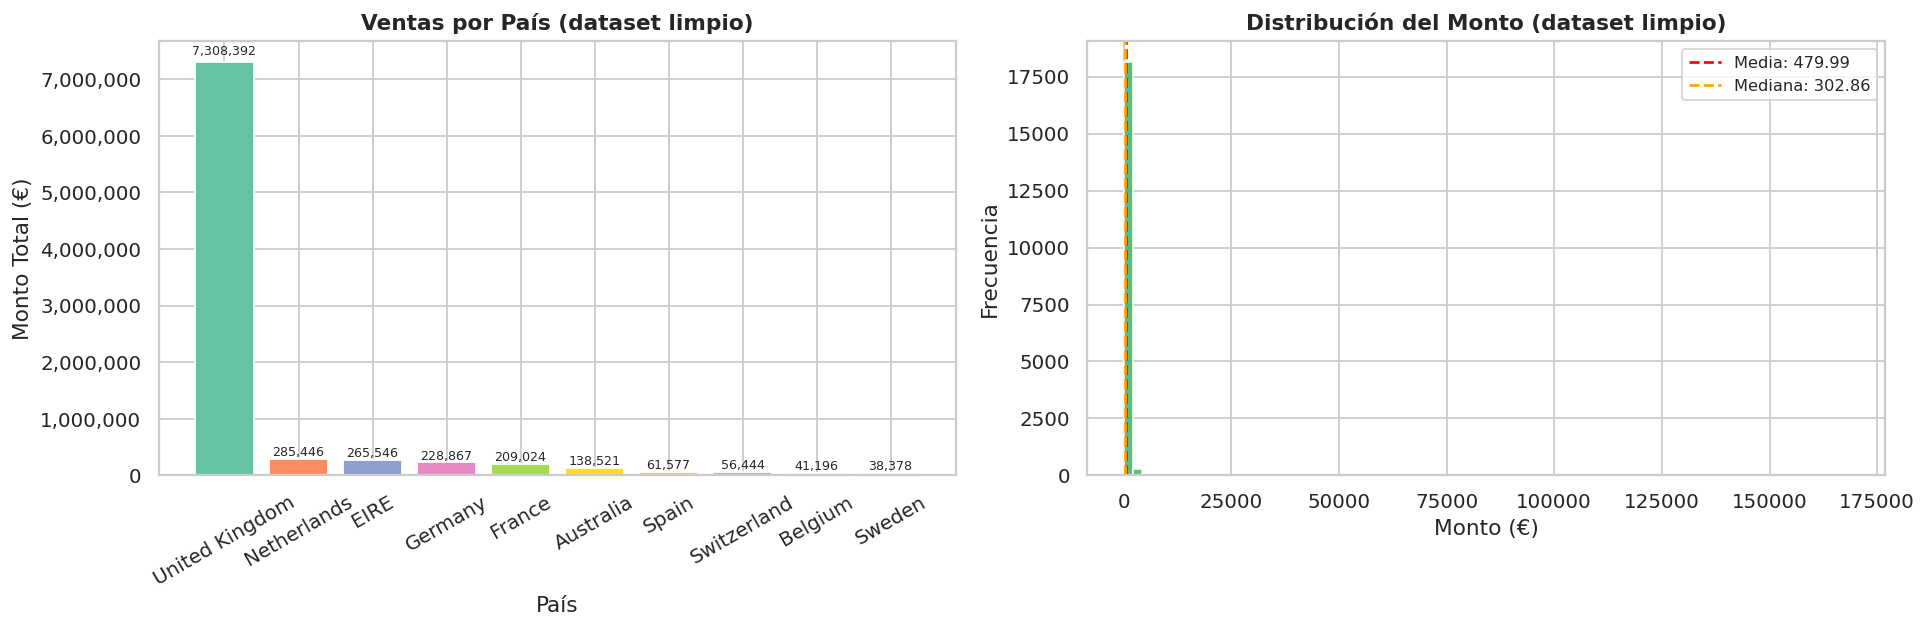

In [11]:
# Ventas por país – datos limpios
ventas_limpio = df.groupby('País')['Monto'].sum().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Gráfica izquierda: ventas por país (limpio) ──────────────────────────────
bars = axes[0].bar(ventas_limpio.index, ventas_limpio.values,
                   color=sns.color_palette('Set2', len(ventas_limpio)))
axes[0].set_title('Ventas por País (dataset limpio)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('País')
axes[0].set_ylabel('Monto Total (€)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].tick_params(axis='x', rotation=30)
for b in bars:
    h = b.get_height()
    axes[0].text(b.get_x() + b.get_width()/2, h + h*0.01,
                 f'{h:,.0f}', ha='center', va='bottom', fontsize=7)

# ── Gráfica derecha: distribución monto (limpio) ─────────────────────────────
axes[1].hist(df['Monto'], bins=80, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribución del Monto (dataset limpio)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Monto (€)')
axes[1].set_ylabel('Frecuencia')
axes[1].axvline(df['Monto'].mean(),   color='red',    linestyle='--', linewidth=1.5,
                label=f"Media: {df['Monto'].mean():.2f}")
axes[1].axvline(df['Monto'].median(), color='orange', linestyle='--', linewidth=1.5,
                label=f"Mediana: {df['Monto'].median():.2f}")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('comparacion_post_limpieza.png', dpi=130, bbox_inches='tight')
plt.show()


## 10. El Principio GIGO y su Impacto en el Análisis y Machine Learning

### ¿Qué es GIGO?
**GIGO** (*Garbage In, Garbage Out*) es el principio que establece que si los datos de entrada
son de mala calidad, los resultados o predicciones obtenidas también serán incorrectos,
independientemente de la sofisticación del algoritmo utilizado.

---

### Problemas encontrados y su impacto si no se corrigen

| Problema detectado | Impacto en Análisis | Impacto en Machine Learning |
|--------------------|--------------------|-----------------------------|
| **3,841 facturas canceladas** | El total de ventas se sobreestima o subestima artificialmente | El modelo aprende patrones de operaciones inválidas, degradando precisión |
| **5,179 cantidades negativas** | Medias y sumas distorsionadas | Regresiones aprenden relaciones inversas incorrectas |
| **3,724 nulos en ID Cliente** | Imposible segmentar por cliente | Modelos de clustering o recomendación no pueden operar correctamente |
| **Monto como texto (coma decimal)** | Sin conversión no se pueden calcular sumas, medias ni percentiles | Las librerías ML rechazan columnas tipo `object`; hay que imputar o perder la columna |
| **Fechas como texto** | No se pueden extraer tendencias temporales, estacionalidad ni ventanas | Series de tiempo, LSTM y modelos secuenciales fallan sin timestamp válido |
| **10 duplicados** | Métricas de conteo y frecuencia infladas | El modelo sobreajusta (overfitting) sobre los registros duplicados |

---

### Reflexión final
> *"Un modelo de Machine Learning es tan bueno como los datos con los que se entrena.
> La limpieza y transformación de datos no es un paso opcional: es el fundamento de
> cualquier análisis confiable y de cualquier modelo predictivo válido."*

Aplicar correctamente las etapas de identificación, limpieza y transformación garantiza
que el principio GIGO no contamine nuestras conclusiones. Los **17,334 registros limpios**
resultantes son la base sólida para construir modelos y reportes de calidad.


## 11. Exportación del Dataset Limpio

In [12]:
import os
os.makedirs('../DataSet', exist_ok=True)

output_path = '../DataSet/Data_Limpio_Factura.csv'
df.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"✅ Dataset limpio exportado → {output_path}")
print(f"   Registros: {len(df):,}  |  Columnas: {df.shape[1]}")
display(df.head(5))


✅ Dataset limpio exportado → ../DataSet/Data_Limpio_Factura.csv
   Registros: 18,566  |  Columnas: 9


,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto,Año,Mes,Día
0,548370,2021-03-30 16:14:00,15528,United Kingdom,123,229.33,2021,3,30
1,575767,2021-11-11 11:11:00,17348,United Kingdom,163,209.73,2021,11,11
3,549106,2021-04-06 12:08:00,17045,United Kingdom,1,39.95,2021,4,6
4,573112,2021-10-27 15:33:00,16416,United Kingdom,357,344.83,2021,10,27
5,576630,2021-11-16 08:38:00,13816,Germany,91,199.98,2021,11,16
